In [1]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive.zip


In [7]:
import zipfile
import os

# Get the name of the uploaded zip file
zip_file_name = list(uploaded.keys())[0]

# Create a ZipFile object
with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    # Extract all the contents into the current directory
    zip_ref.extractall('.')

# Verify that the CSV file now exists
print(f"Files extracted: {os.listdir('.')}")

Files extracted: ['.config', 'ecommerce_customer_data_large.csv', 'archive.zip', 'ecommerce_customer_data_custom_ratios.csv', 'sample_data']


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

plt.rcParams["figure.figsize"] = (10,5)

In [10]:
df = pd.read_csv("ecommerce_customer_data_large.csv")
df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,44605,2023-05-03 21:30:02,Home,177,1,2427,PayPal,31,1.0,John Rivera,31,Female,0
1,44605,2021-05-16 13:57:44,Electronics,174,3,2448,PayPal,31,1.0,John Rivera,31,Female,0
2,44605,2020-07-13 06:16:57,Books,413,1,2345,Credit Card,31,1.0,John Rivera,31,Female,0
3,44605,2023-01-17 13:14:36,Electronics,396,3,937,Cash,31,0.0,John Rivera,31,Female,0
4,44605,2021-05-01 11:29:27,Books,259,4,2598,PayPal,31,1.0,John Rivera,31,Female,0


In [11]:
print(df.shape)
print(df.columns)
df.info()

(250000, 13)
Index(['Customer ID', 'Purchase Date', 'Product Category', 'Product Price',
       'Quantity', 'Total Purchase Amount', 'Payment Method', 'Customer Age',
       'Returns', 'Customer Name', 'Age', 'Gender', 'Churn'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  object 
 2   Product Category       250000 non-null  object 
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  object 
 7   Customer Age           250000 non-null  int64  
 8   Returns                202618 non-null  float64
 9   Customer Name          250000 non-null  object 
 1

In [12]:
df.describe()

,Customer ID,Product Price,Quantity,Total Purchase Amount,Customer Age,Returns,Age,Churn
count,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,202618.000000,250000.000000,250000.00000
mean,25017.632092,254.742724,3.004936,2725.385196,43.798276,0.500824,43.798276,0.20052
std,14412.515718,141.738104,1.414737,1442.576095,15.364915,0.500001,15.364915,0.40039
min,1.000000,10.000000,1.000000,100.000000,18.000000,0.000000,18.000000,0.00000
25%,12590.000000,132.000000,2.000000,1476.000000,30.000000,0.000000,30.000000,0.00000
50%,25011.000000,255.000000,3.000000,2725.000000,44.000000,1.000000,44.000000,0.00000
75%,37441.250000,377.000000,4.000000,3975.000000,57.000000,1.000000,57.000000,0.00000
max,50000.000000,500.000000,5.000000,5350.000000,70.000000,1.000000,70.000000,1.00000


In [13]:
df.isnull().sum()

,0
Customer ID,0
Purchase Date,0
Product Category,0
Product Price,0
Quantity,0
Total Purchase Amount,0
Payment Method,0
Customer Age,0
Returns,47382
Customer Name,0


In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df = df.drop_duplicates()

In [16]:
df = df.fillna(0)

In [19]:
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])

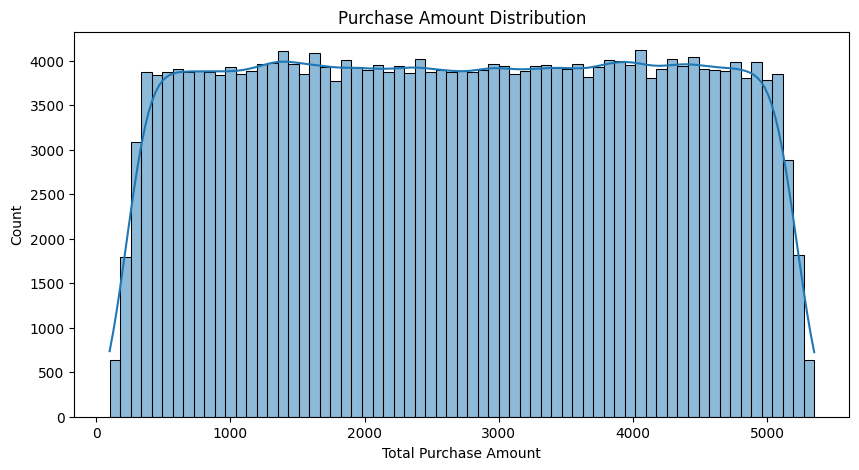

In [21]:
sns.histplot(df['Total Purchase Amount'], kde=True)
plt.title("Purchase Amount Distribution")
plt.show()

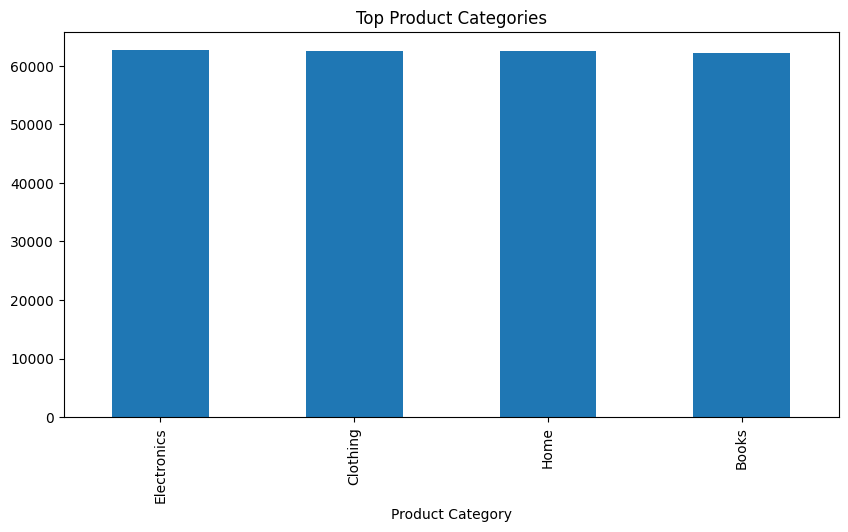

In [23]:
df['Product Category'].value_counts().plot(kind='bar')
plt.title("Top Product Categories")
plt.show()

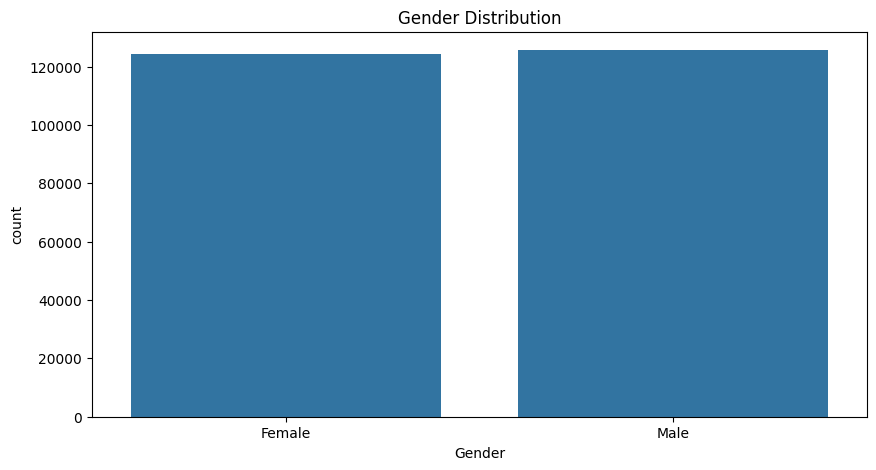

In [24]:
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.show()

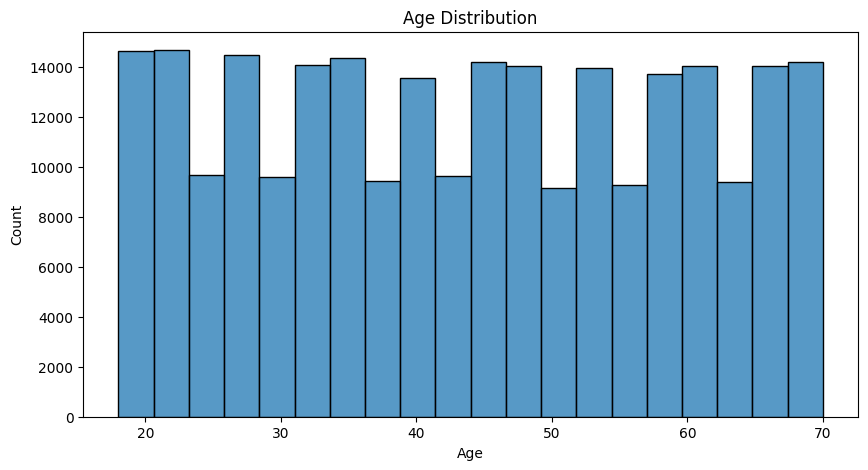

In [25]:
sns.histplot(df['Age'], bins=20)
plt.title("Age Distribution")
plt.show()

In [27]:
snapshot_date = df['Purchase Date'].max()

In [29]:
rfm = df.groupby('Customer ID').agg({
    'Purchase Date': lambda x: (snapshot_date - x.max()).days,
    'Customer ID': 'count',
    'Total Purchase Amount': 'sum'
})

In [30]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
1,288,3,6290
2,72,6,16481
3,222,4,9423
4,441,5,7826
5,424,5,9769


In [31]:
rfm['R'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])

rfm['F'] = pd.qcut(rfm['Frequency'].rank(method='first'),
                   5,
                   labels=[1,2,3,4,5])

rfm['M'] = pd.qcut(rfm['Monetary'],
                   5,
                   labels=[1,2,3,4,5])

In [35]:
rfm['RFM_Score'] = rfm['R'].astype(str) + rfm['F'].astype(str) + rfm['M'].astype(str)

def segment(row):
    if row['RFM_Score'] == '555':
        return 'Champions'
    elif row['R'] >= 4:
        return 'Loyal'
    elif row['R'] <= 2:
        return 'At Risk'
    else:
        return 'Regular'

rfm['Segment'] = rfm.apply(segment, axis=1)

In [36]:
rfm['Segment'].value_counts()

,count
Segment,
At Risk,19848
Loyal,17787
Regular,9841
Champions,2185


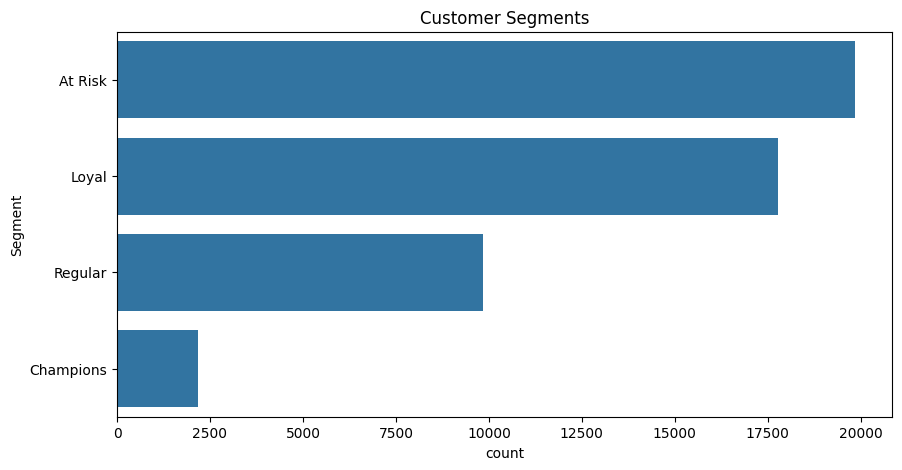

In [37]:
sns.countplot(y=rfm['Segment'])
plt.title("Customer Segments")
plt.show()

In [38]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    rfm[['Recency','Frequency','Monetary']]
)

In [39]:
kmeans = KMeans(n_clusters=4, random_state=42)

rfm['Cluster'] = kmeans.fit_predict(X_scaled)

In [41]:
rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

,Recency,Frequency,Monetary
Cluster,,,
0,195.303943,3.420781,8540.961840
1,137.535687,8.536975,24754.201881
2,720.101699,2.924314,7797.505752
3,179.827512,5.803633,15927.435694


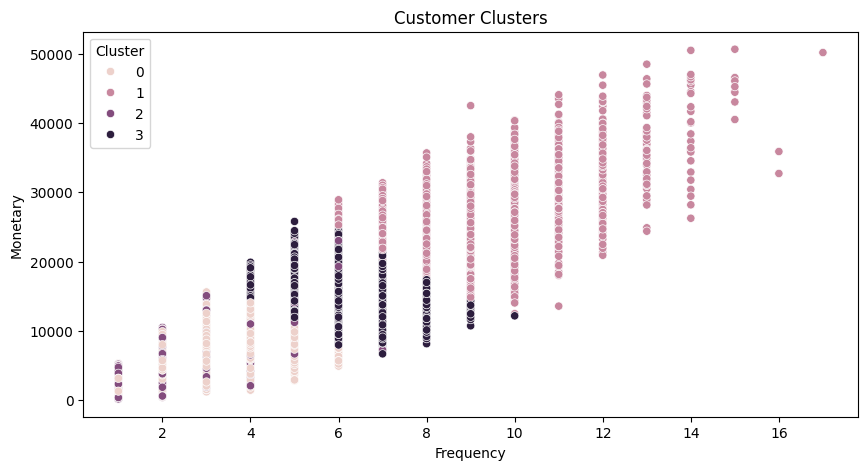

In [42]:
sns.scatterplot(
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    data=rfm
)

plt.title("Customer Clusters")
plt.show()

In [43]:
rfm['Churn_Risk'] = np.where(
    rfm['Recency'] > 90,
    'High',
    'Low'
)

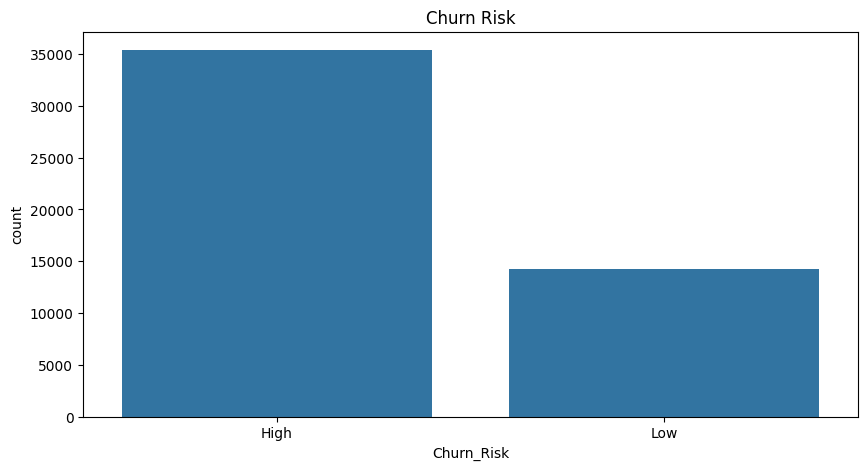

In [44]:
sns.countplot(
    x='Churn_Risk',
    data=rfm
)

plt.title("Churn Risk")
plt.show()

1. Most revenue comes from Champions and Loyal customers.
2. High Recency customers are at churn risk.
3. Product Category X generates highest sales.
4. Cluster 1 contains high-value customers.
5. Retention drops after first few months.

1. Launch loyalty rewards for Champions.
2. Send discounts to At-Risk customers.
3. Create personalized recommendations.
4. Improve retention campaigns.
5. Focus marketing on profitable segments.